# Diabetes prediction 

Diabetes is one of the most fastly growing disease that cause death


In [208]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

In [209]:
path=r"C:\artificial_intelligence_coarse\mydatasetkaggle\Dataset of Diabetes.csv"

In [210]:
df=pd.read_csv(path)

In [211]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   str    
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   str    
dtypes: float64(8), int64(4), str(2)
memory usage: 111.5 KB


In [212]:
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [213]:
df=df.drop(["ID",'No_Pation'],axis=1)

In [214]:
df

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...
995,M,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0,Y
996,M,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2,Y
997,M,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4,Y
998,M,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5,Y


In [215]:
df.columns

Index(['Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL',
       'VLDL', 'BMI', 'CLASS'],
      dtype='str')

In [216]:
l=['Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL',
       'VLDL', 'BMI', 'CLASS']

In [217]:
l=pd.Series(l).apply(lambda s: s.lower())
l=list(l)
l

['gender',
 'age',
 'urea',
 'cr',
 'hba1c',
 'chol',
 'tg',
 'hdl',
 'ldl',
 'vldl',
 'bmi',
 'class']

In [218]:
df.columns=l

In [219]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gender  1000 non-null   str    
 1   age     1000 non-null   int64  
 2   urea    1000 non-null   float64
 3   cr      1000 non-null   int64  
 4   hba1c   1000 non-null   float64
 5   chol    1000 non-null   float64
 6   tg      1000 non-null   float64
 7   hdl     1000 non-null   float64
 8   ldl     1000 non-null   float64
 9   vldl    1000 non-null   float64
 10  bmi     1000 non-null   float64
 11  class   1000 non-null   str    
dtypes: float64(8), int64(2), str(2)
memory usage: 95.8 KB


In [220]:
df.gender.unique()

<ArrowStringArray>
['F', 'M', 'f']
Length: 3, dtype: str

In [221]:
df['gender']=df['gender'].apply(lambda s: s.title())

In [222]:
df.gender.unique()

<ArrowStringArray>
['F', 'M']
Length: 2, dtype: str

In [223]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gender  1000 non-null   str    
 1   age     1000 non-null   int64  
 2   urea    1000 non-null   float64
 3   cr      1000 non-null   int64  
 4   hba1c   1000 non-null   float64
 5   chol    1000 non-null   float64
 6   tg      1000 non-null   float64
 7   hdl     1000 non-null   float64
 8   ldl     1000 non-null   float64
 9   vldl    1000 non-null   float64
 10  bmi     1000 non-null   float64
 11  class   1000 non-null   str    
dtypes: float64(8), int64(2), str(2)
memory usage: 95.8 KB


In [224]:
df['class'].unique()

<ArrowStringArray>
['N', 'N ', 'P', 'Y', 'Y ']
Length: 5, dtype: str

In [225]:
df['class']=df['class'].apply(lambda s: s.title().replace(' ',''))

In [226]:
df['class'].unique()

<ArrowStringArray>
['N', 'P', 'Y']
Length: 3, dtype: str

In [227]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gender  1000 non-null   str    
 1   age     1000 non-null   int64  
 2   urea    1000 non-null   float64
 3   cr      1000 non-null   int64  
 4   hba1c   1000 non-null   float64
 5   chol    1000 non-null   float64
 6   tg      1000 non-null   float64
 7   hdl     1000 non-null   float64
 8   ldl     1000 non-null   float64
 9   vldl    1000 non-null   float64
 10  bmi     1000 non-null   float64
 11  class   1000 non-null   str    
dtypes: float64(8), int64(2), str(2)
memory usage: 95.8 KB


In [228]:
df.head()

,gender,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,class
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [229]:
df=pd.get_dummies(df,columns=["gender"],dtype=int)

In [230]:
df

,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,class,gender_F,gender_M
0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,1,0
1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N,0,1
2,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,1,0
3,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,1,0
4,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0,Y,0,1
996,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2,Y,0,1
997,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4,Y,0,1
998,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5,Y,0,1


In [231]:
df=pd.get_dummies(df,
                  columns=['class'],dtype=int)

In [232]:
df.head()

,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,gender_F,gender_M,class_N,class_P,class_Y
0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0,1,0,0
1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0,1,1,0,0
2,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0,1,0,0
3,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0,1,0,0
4,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0,1,1,0,0


In [233]:
df.rename(columns={
          "class_N":"diabetic",
          "class_P":'prediabetic',
          "class_Y":"non_diabetic"
            },inplace=True)

In [234]:
df

,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,gender_F,gender_M,diabetic,prediabetic,non_diabetic
0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0,1,0,0
1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0,1,1,0,0
2,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0,1,0,0
3,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0,1,0,0
4,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0,0,1,0,0,1
996,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2,0,1,0,0,1
997,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4,0,1,0,0,1
998,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5,0,1,0,0,1


In [236]:
df

,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,gender_F,gender_M,diabetic,prediabetic,non_diabetic
0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0,1,0,0
1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0,1,1,0,0
2,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0,1,0,0
3,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0,1,0,0
4,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0,0,1,0,0,1
996,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2,0,1,0,0,1
997,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4,0,1,0,0,1
998,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5,0,1,0,0,1


In [238]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1000 non-null   int64  
 1   urea          1000 non-null   float64
 2   cr            1000 non-null   int64  
 3   hba1c         1000 non-null   float64
 4   chol          1000 non-null   float64
 5   tg            1000 non-null   float64
 6   hdl           1000 non-null   float64
 7   ldl           1000 non-null   float64
 8   vldl          1000 non-null   float64
 9   bmi           1000 non-null   float64
 10  gender_F      1000 non-null   int64  
 11  gender_M      1000 non-null   int64  
 12  diabetic      1000 non-null   int64  
 13  prediabetic   1000 non-null   int64  
 14  non_diabetic  1000 non-null   int64  
dtypes: float64(8), int64(7)
memory usage: 117.3 KB


In [241]:
df.describe().round(0)

,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,gender_F,gender_M,diabetic,prediabetic,non_diabetic
count,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
mean,54.0,5.0,69.0,8.0,5.0,2.0,1.0,3.0,2.0,30.0,0.0,1.0,0.0,0.0,1.0
std,9.0,3.0,60.0,3.0,1.0,1.0,1.0,1.0,4.0,5.0,0.0,0.0,0.0,0.0,0.0
min,20.0,0.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,0.0,0.0
25%,51.0,4.0,48.0,6.0,4.0,2.0,1.0,2.0,1.0,26.0,0.0,0.0,0.0,0.0,1.0
50%,55.0,5.0,60.0,8.0,5.0,2.0,1.0,2.0,1.0,30.0,0.0,1.0,0.0,0.0,1.0
75%,59.0,6.0,73.0,10.0,6.0,3.0,1.0,3.0,2.0,33.0,1.0,1.0,0.0,0.0,1.0
max,79.0,39.0,800.0,16.0,10.0,14.0,10.0,10.0,35.0,48.0,1.0,1.0,1.0,1.0,1.0


In [243]:
sum(df.diabetic)

103

In [244]:
sum(df.prediabetic)

53

In [245]:
sum(df.non_diabetic)

844

In [251]:
df=df.drop(["prediabetic"],axis=1)

In [253]:
df['diabetes'] = (df['diabetic'] == 1).astype(int)

In [258]:
df=df.drop(['diabetic','non_diabetic'],axis=1)

In [266]:
df.head()

,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,gender_F,gender_M,diabetes
2,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0,1
3,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0,1
4,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0,1,1
5,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,1,0,1
6,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,1,0,1


In [265]:
df.corrwith(df['diabetes']).drop("diabetes")

age        -0.352527
urea       -0.050692
cr         -0.033565
hba1c      -0.495160
chol       -0.151938
tg         -0.171840
hdl         0.006702
ldl         0.009349
vldl       -0.082936
bmi        -0.489911
gender_F    0.127857
gender_M   -0.127857
dtype: float64

In [268]:
numeric=['age','urea','cr','hba1c','chol','tg','bmi']
binary=['gender_F','gender_M']

<Axes: >

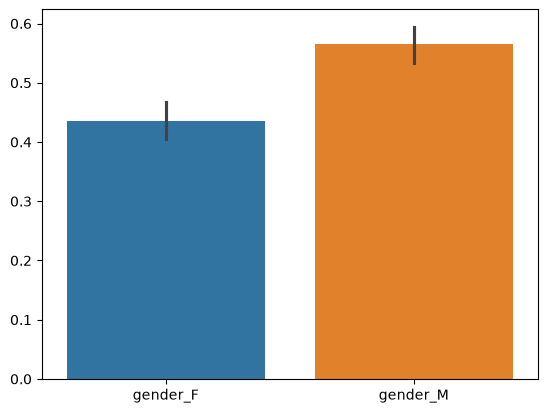

In [273]:
sns.barplot(data=df[['gender_F','gender_M']])

<Axes: >

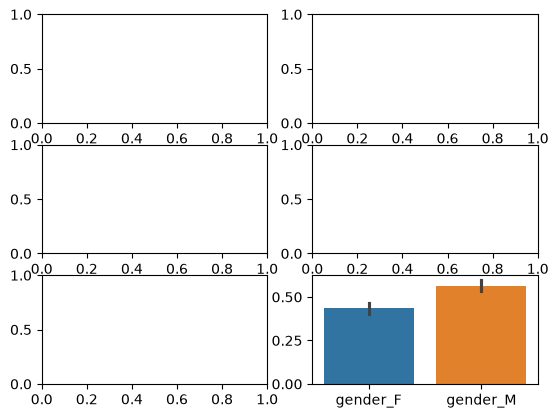

In [272]:
plt.subplots(3,2)
sns.barplot(data=df[['gender_F','gender_M']])

In [275]:
feature=['age','urea','cr','hba1c','chol','tg','bmi','gender_F','gender_M']

In [276]:
x=df[feature]

In [277]:
y=df['diabetes']

In [279]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=4)

In [284]:
model=LogisticRegression(max_iter=500)

In [285]:
model.fit(xtrain,ytrain)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [286]:
pred=model.predict(xtest)

In [287]:
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0])

In [288]:
np.array(ytest)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0])

In [289]:
accuracy_score(ytest,pred)

0.97

In [290]:
from sklearn.metrics import confusion_matrix

In [291]:
cm=confusion_matrix(ytest,pred)
cm

array([[180,   2],
       [  4,  14]])

Text(0.5, 1.0, 'model and actual prediction')

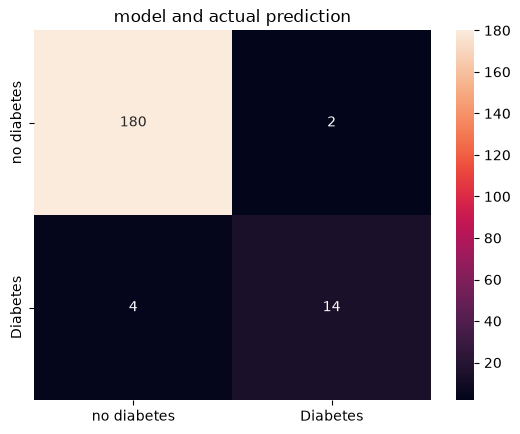

In [317]:
sns.heatmap(data=cm,annot=True,fmt='d',xticklabels=['no diabetes','Diabetes'],yticklabels=['no diabetes','Diabetes'])
plt.title("model and actual prediction")

In [297]:
feature

['age', 'urea', 'cr', 'hba1c', 'chol', 'tg', 'bmi', 'gender_F', 'gender_M']

In [307]:
l=[100,50,4,5.8,10,5,30,1,0]
check=np.array(l).reshape(1,-1)

In [308]:
model.predict(check)

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [315]:
b=df[df['diabetes']==1].iloc[0,10]
b

np.int64(1)

In [316]:
model.predict(b)

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


ValueError: Expected 2D array, got scalar array instead:
array=1.
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.